## Đồ Án 1

## Import data
Lưu ý: Tọa độ thành phố Hồ Chí Minh chỉ từ 10.38-11.10 vĩ độ bắc và 106.22-106.56 kinh độ đông

In [499]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np



In [500]:
df = pd.read_csv("data.csv")
df = df[:36000]

In [501]:
df.shape

(36000, 11)

In [502]:
# Lọc trùng lặp
df = df.drop_duplicates()
df.shape

(13578, 11)

In [503]:
# Bởi vì data tạo độ lúc crawl có nhân 1 tỷ nên cần chia lại cho đúng
df["tọa độ x"], df["tọa độ y"] = df["tọa độ x"]/1000000000, df["tọa độ y"]/1000000000
df.drop(columns=["giá"], inplace=True)

Thêm khoảng cách từ vị trí bất động sản để trung tâm thành phố, là vị trí của nhà thờ Đức Bà (lat:10.7769, lon:106.7009)

In [504]:
lat = 10.7769
lon = 106.7009

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + \
        np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))

    return R*c

df["cách trung tâm"] = haversine(
    df["tọa độ x"],
    df["tọa độ y"],
    lat,
    lon
)

In [505]:
df.head()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
0,0,23,88.8,73.09,NaN,2.0,NaN,10.803385,106.617524,NaN,9.571355
1,2,5,47.0,92.55,4.0,2.0,1.0,10.842744,106.642948,2.0,9.678252
2,7,21,216.0,82.87,12.0,NaN,1.0,10.842596,106.717190,NaN,7.518595
3,0,18,65.0,76.92,NaN,2.0,2.0,10.750351,106.723175,NaN,3.825693
4,4,0,128.0,58.59,6.0,5.0,1.0,10.669288,106.613250,3.0,15.325910


In [506]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13578 entries, 0 to 35997
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loại nhà đất    13578 non-null  int64  
 1   địa chỉ         13578 non-null  int64  
 2   diện tích       13578 non-null  float64
 3   giá/m2          13578 non-null  float64
 4   mặt tiền        7979 non-null   float64
 5   phòng ngủ       9329 non-null   float64
 6   pháp lý         11177 non-null  float64
 7   tọa độ x        13578 non-null  float64
 8   tọa độ y        13578 non-null  float64
 9   số tầng         6253 non-null   float64
 10  cách trung tâm  13578 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [507]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,13578.000000,13578.000000,13578.000000,13578.000000,7979.000000,9329.000000,11177.000000,13578.000000,13578.000000,6253.000000,13578.000000
mean,2.461776,13.084401,117.466769,145.346117,7.327060,3.824526,1.125436,10.980567,106.654208,3.569647,32.279114
std,2.208320,7.173167,109.957557,241.521413,19.838301,4.667340,0.331228,1.403349,1.772754,1.749551,247.456271
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.023074
25%,0.000000,7.000000,60.000000,69.625000,4.000000,2.000000,1.000000,10.763086,106.656240,2.000000,4.145155
50%,2.000000,13.000000,83.050000,109.330000,5.000000,3.000000,1.000000,10.793201,106.698822,3.000000,6.967718
75%,4.000000,20.000000,127.000000,173.467500,7.000000,4.000000,1.000000,10.825368,106.736917,4.000000,10.164062
max,7.000000,23.000000,996.000000,23000.000000,764.000000,115.000000,2.000000,25.457272,106.975829,25.000000,11830.911635


In [508]:
REAL_ESTATE_ = {
    'căn hộ chung cư': 0,
    'chung cư mini, căn hộ dịch vụ': 1, # X
    'nhà riêng': 2, 
    'nhà biệt thự, liền kề':3,
    'nhà mặt phố': 4,
    'shophouse, nhà phố thương mại': 5,# X
    'đất nền dự án': 6, # X
    'bán đất': 7,
    'condotel': 8, # X
    'kho nhà xưởng': 9 # X
}


ADDRESS_ = {
    'bình chánh':0, 
    'bình tân':1,  #
    'bình thạnh':2, #
    'cần giờ':3,
    'củ chi':4,
    'gò vấp':5,#
    'hóc môn':6,
    'nhà bè':7,
    'phú nhuận':8,
    'quận 1':9,
    'quận 10':10,
    'quận 11':11,
    'quận 12':12,#
    'quận 2':13,#
    'quận 3':14,
    'quận 4':15,
    'quận 5':16,
    'quận 6':17,
    'quận 7':18,#
    'quận 8':19,
    'quận 9':20,#
    'thủ đức':21,#
    'tân bình':22,#
    'tân phú':23 #
}

In [509]:
# print(df["loại nhà đất"].value_counts())
for i in df.value_counts("loại nhà đất").index:
    for j in REAL_ESTATE_:
        if i == REAL_ESTATE_[j]:
            print(f"{j}: {df.value_counts('loại nhà đất')[i]}") 

căn hộ chung cư: 4192
nhà riêng: 4113
nhà mặt phố: 2498
bán đất: 1338
nhà biệt thự, liền kề: 884
đất nền dự án: 437
shophouse, nhà phố thương mại: 113
chung cư mini, căn hộ dịch vụ: 3


In [510]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,13578.000000,13578.000000,13578.000000,13578.000000,7979.000000,9329.000000,11177.000000,13578.000000,13578.000000,6253.000000,13578.000000
mean,2.461776,13.084401,117.466769,145.346117,7.327060,3.824526,1.125436,10.980567,106.654208,3.569647,32.279114
std,2.208320,7.173167,109.957557,241.521413,19.838301,4.667340,0.331228,1.403349,1.772754,1.749551,247.456271
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.023074
25%,0.000000,7.000000,60.000000,69.625000,4.000000,2.000000,1.000000,10.763086,106.656240,2.000000,4.145155
50%,2.000000,13.000000,83.050000,109.330000,5.000000,3.000000,1.000000,10.793201,106.698822,3.000000,6.967718
75%,4.000000,20.000000,127.000000,173.467500,7.000000,4.000000,1.000000,10.825368,106.736917,4.000000,10.164062
max,7.000000,23.000000,996.000000,23000.000000,764.000000,115.000000,2.000000,25.457272,106.975829,25.000000,11830.911635


## Loại bỏ những data không cần thết

In [511]:
# Ta thấy lượng data của "shophoue, nhà phố thương mại" 
# và "chung cư mini, căn hộ dịch vụ" khá ít. 
# Ta quyết định bỏ đi những data này
mask_remove_real_estate = (
    (df["loại nhà đất"] == REAL_ESTATE_["shophouse, nhà phố thương mại"])
    | (df["loại nhà đất"] == REAL_ESTATE_["chung cư mini, căn hộ dịch vụ"])
    | (df["loại nhà đất"] == REAL_ESTATE_["đất nền dự án"])
)
df.drop(df[mask_remove_real_estate].index, inplace=True)


# Khu vực thành phố hồ chí minh chỉ từ 10.38-11.10 vĩ độ bắc và 106.22-106.56 kinh độ đông.
# Loại bỏ những data ngoài khu vực
remove_out_of_city = (
    (df["tọa độ y"] < 106.1) | (df["tọa độ y"] > 106.8)
    | (df["tọa độ x"] < 10.38) | (df["tọa độ x"] > 11.10)
)
df.drop(df[remove_out_of_city].index, inplace=True)


# Hầu hết các nhà đều có sổ đỏ, sổ hồng. Với các nhà chỉ ở dạng 
# hợp đồng rất hạn chế nên có thể bỏ các data có dữ liệu này
df.drop(df[df["pháp lý"] == 2].index, inplace=True)
df.drop(df[df["pháp lý"].isna()].index, inplace=True)
df.drop(columns=["pháp lý"], inplace=True)

In [512]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,8873.000000,8873.000000,8873.000000,8873.000000,6402.000000,6336.000000,8873.000000,8873.000000,5235.000000,8873.000000
mean,2.728051,12.532402,117.517139,150.831650,6.903132,4.318655,10.793649,106.687921,3.500096,7.354284
std,2.068016,7.361610,113.249792,149.884338,14.244333,4.987746,0.053406,0.056455,1.659651,4.967423
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,79.310000,4.000000,2.000000,10.762362,106.651018,2.000000,3.991797
50%,2.000000,13.000000,83.000000,117.330000,5.000000,3.000000,10.793240,106.690399,3.000000,6.632817
75%,4.000000,20.000000,126.000000,181.820000,7.000000,4.000000,10.825189,106.725703,4.000000,9.665030
max,7.000000,23.000000,996.000000,6300.000000,737.000000,115.000000,11.092275,106.799964,25.000000,47.974788


## Plot dữ liệu

In [513]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

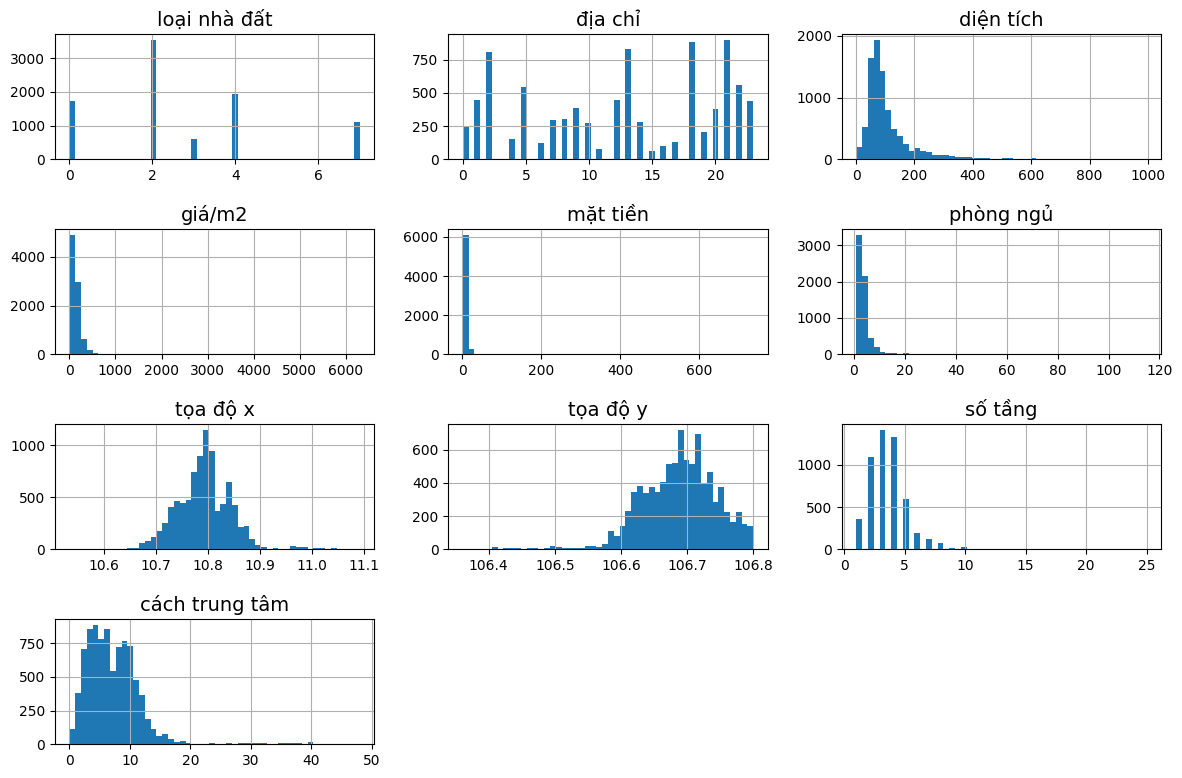

In [514]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Create data test

Giữ nguyên tỷ lệ phân bố của một biến quan trọng
trong cả train và test

In [515]:
np.random.seed(42)

In [ ]:
df["distance_center_cat"] = pd.cut(df["cách trung tâm"],
                                    bins=[0., 5., 10., 15., np.inf],
                                    labels=[1, 2, 3, 4])

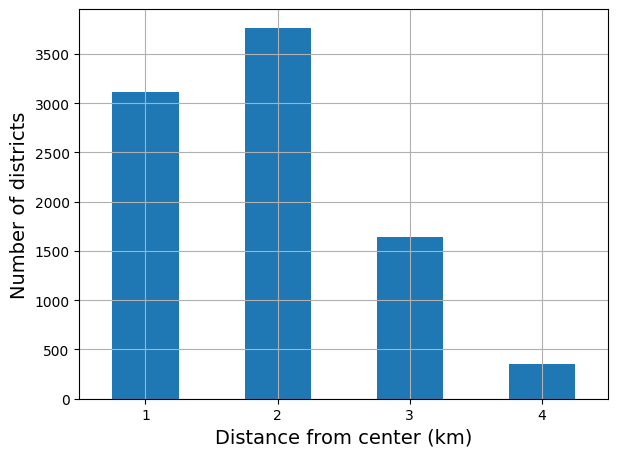

In [517]:
df["distance_center_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Distance from center (km)")
plt.ylabel("Number of districts")
save_fig("housing_distance_cat_bar_plot")  # extra code
plt.show()

In [518]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(df, df["distance_center_cat"]):
    strat_train_set_n = df.iloc[train_index]
    strat_test_set_n = df.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [519]:
strat_train_set, strat_test_set = strat_splits[0]

In [520]:
df["distance_center_cat"].value_counts() / len(df)

distance_center_cat
2    0.424659
1    0.350727
3    0.185394
4    0.039220
Name: count, dtype: float64

In [521]:
strat_train_set["distance_center_cat"].value_counts() / len(strat_train_set)

distance_center_cat
2    0.424627
1    0.350803
3    0.185404
4    0.039166
Name: count, dtype: float64

In [522]:
strat_test_set["distance_center_cat"].value_counts() / len(strat_test_set)

distance_center_cat
2    0.424789
1    0.350423
3    0.185352
4    0.039437
Name: count, dtype: float64

In [523]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("distance_center_cat", axis=1, inplace=True)

C:\Users\huy\AppData\Local\Temp\ipykernel_8248\3306667349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("distance_center_cat", axis=1, inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\3306667349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("distance_center_cat", axis=1, inplace=True)


In [524]:
train_set = strat_train_set
test_set = strat_test_set

In [525]:
print(f"train set shape: {train_set.shape}")
print(f"test set shape: {test_set.shape}")

train set shape: (7098, 10)
test set shape: (1775, 10)


# Discover and Visualize the Data to Gain Insights

In [526]:
housing = train_set.copy()

## Visualizing Geographical Data

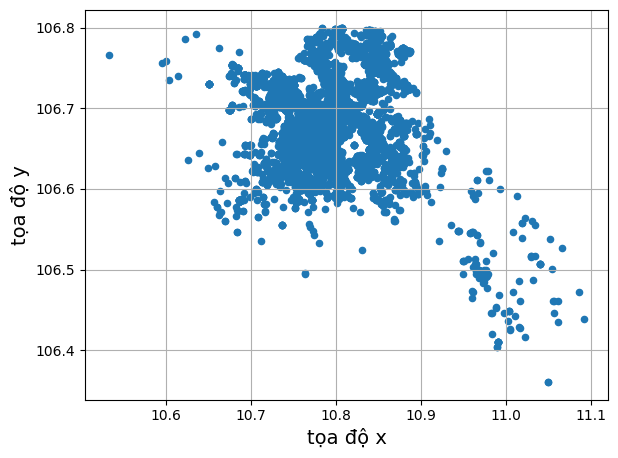

In [527]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True)
save_fig("bad_visualization_plot")  # extra code
plt.show()

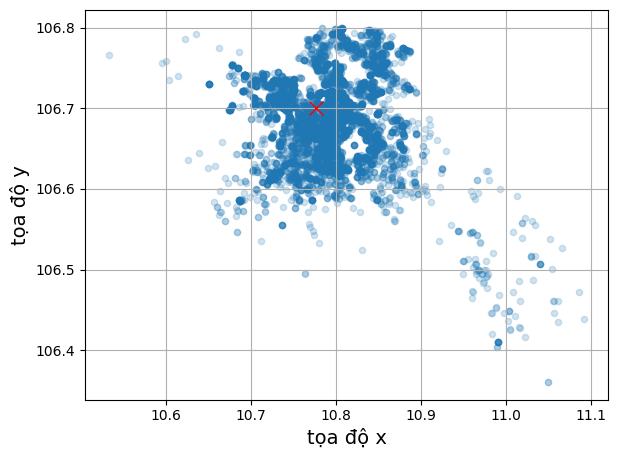

In [528]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True, alpha=0.2)
# vẽ dấu x biểu thị trung tâm thành phố
plt.plot(lat, lon, "x", color="red", markersize=10, label="Trung tâm thành phố")
save_fig("better_visualization_plot")  # extra code
plt.show()

# Biểu đồ tương quan các feature

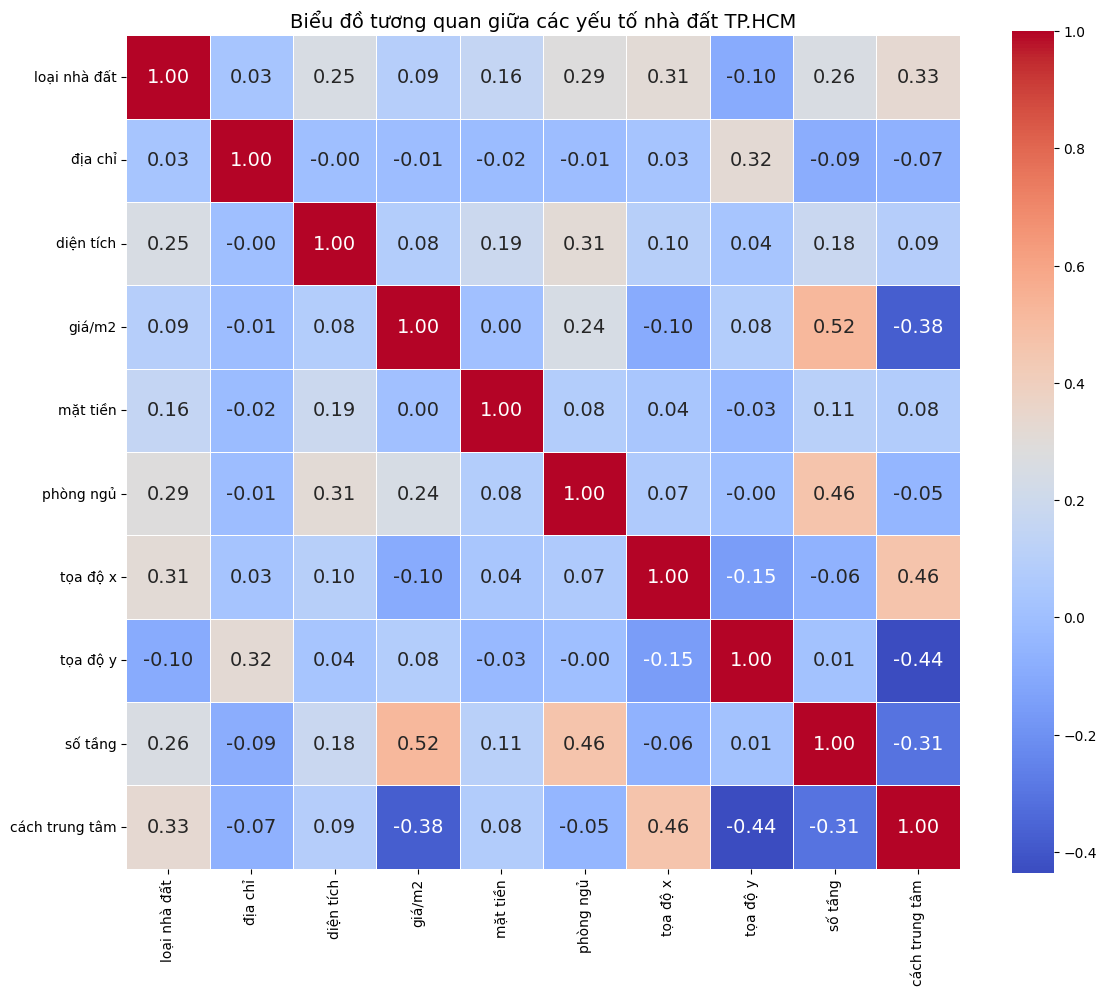

In [529]:
import seaborn as sns

corr_matrix = housing.corr(numeric_only=True)

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 10))

# 3. Vẽ heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Hiển thị số liệu trên từng ô
            fmt=".2f",        # Làm tròn 2 chữ số thập phân
            cmap='coolwarm',  # Màu sắc (Đỏ: tương quan thuận, Xanh: tương quan nghịch)
            linewidths=0.5,   # Khoảng cách giữa các ô
            square=True)      # Giữ các ô là hình vuông

plt.title('Biểu đồ tương quan giữa các yếu tố nhà đất TP.HCM')
save_fig("correlation_heatmap")  # extra code
plt.show()

In [530]:
corr_matrix = housing.corr(numeric_only=True)

In [531]:
corr_matrix["giá/m2"].sort_values(ascending=False)

giá/m2            1.000000
số tầng           0.520220
phòng ngủ         0.244980
loại nhà đất      0.091494
diện tích         0.081937
tọa độ y          0.080296
mặt tiền          0.003354
địa chỉ          -0.014013
tọa độ x         -0.097354
cách trung tâm   -0.375599
Name: giá/m2, dtype: float64

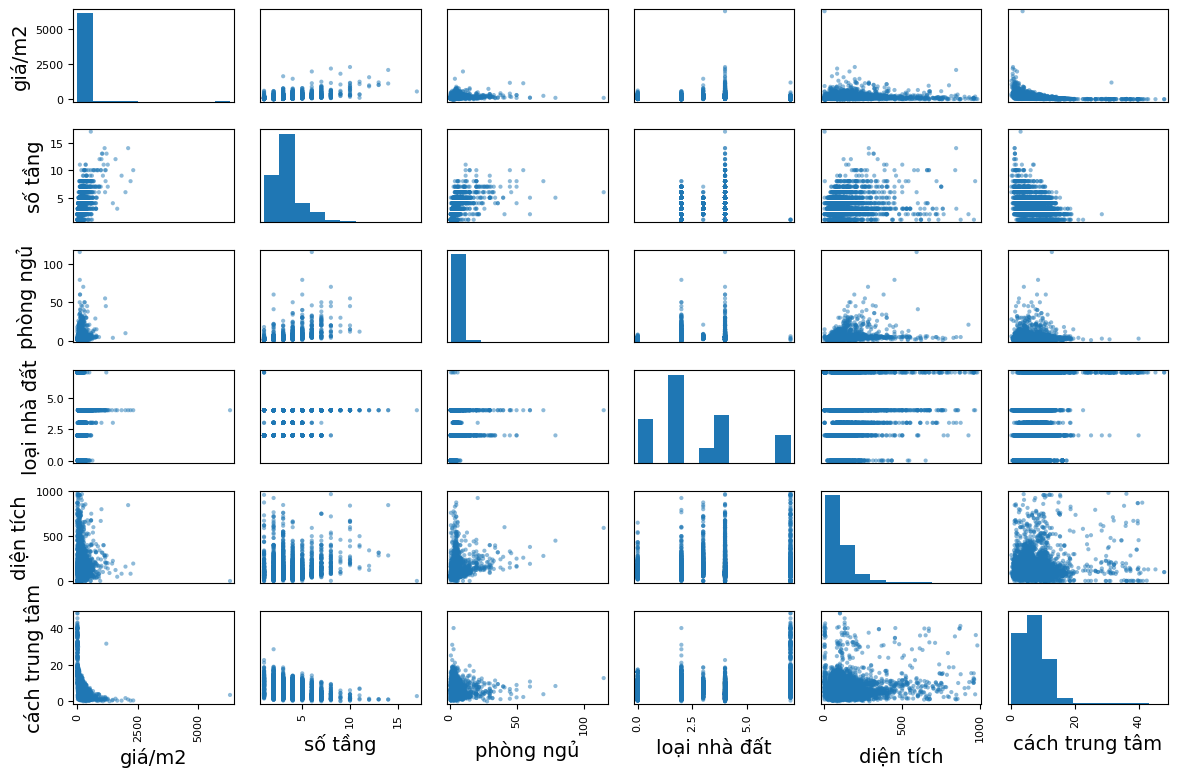

In [532]:
from pandas.plotting import scatter_matrix

attributes = ["giá/m2", "số tầng", "phòng ngủ", "loại nhà đất", "diện tích", "cách trung tâm"]

scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()  

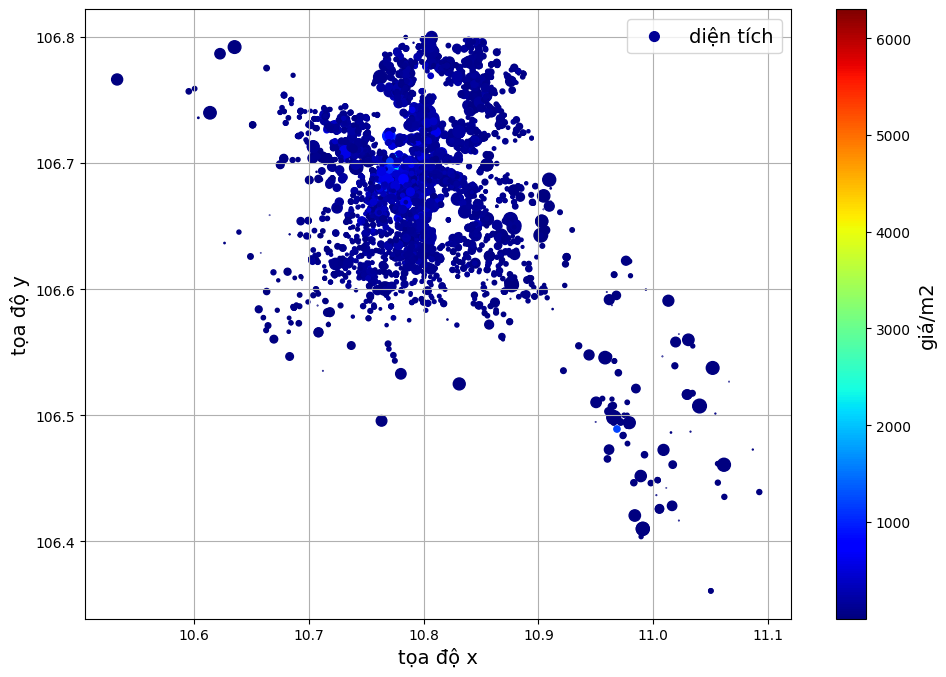

In [533]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_prices_scatterplot")  # extra code
plt.show()

## Data cleaning


In [534]:
housing.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,7098.000000,7098.000000,7098.000000,7098.000000,5116.000000,5086.000000,7098.000000,7098.000000,4192.000000,7098.000000
mean,2.720203,12.519019,117.513495,150.339542,6.916591,4.264648,10.793363,106.688428,3.487118,7.350836
std,2.069332,7.388568,113.795660,153.575031,15.067411,4.680590,0.053405,0.056492,1.627820,4.949758
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,5.250000,60.000000,78.972500,4.000000,2.000000,10.761543,106.651667,2.000000,4.003556
50%,2.000000,13.000000,83.000000,116.845000,5.000000,3.000000,10.793132,106.690781,3.000000,6.612624
75%,4.000000,20.000000,126.000000,181.360000,7.000000,4.000000,10.824710,106.726120,4.000000,9.666572
max,7.000000,23.000000,982.000000,6300.000000,737.000000,115.000000,11.092275,106.799964,17.000000,47.974788


In [535]:
def set_median_none_in_column(df, column_names):
    for column_name in column_names:
        median_value = df[column_name].median()
        df[column_name] = df[column_name].fillna(median_value)

set_median_none_in_column(housing, ["số tầng", "phòng ngủ", "mặt tiền"])


In [536]:
housing.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000
mean,2.720203,12.519019,117.513495,150.339542,6.381414,3.906171,10.793363,106.688428,3.287687,7.350836
std,2.069332,7.388568,113.795660,153.575031,12.820445,4.002738,0.053405,0.056492,1.273645,4.949758
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,5.250000,60.000000,78.972500,4.000000,3.000000,10.761543,106.651667,3.000000,4.003556
50%,2.000000,13.000000,83.000000,116.845000,5.000000,3.000000,10.793132,106.690781,3.000000,6.612624
75%,4.000000,20.000000,126.000000,181.360000,5.700000,4.000000,10.824710,106.726120,4.000000,9.666572
max,7.000000,23.000000,982.000000,6300.000000,737.000000,115.000000,11.092275,106.799964,17.000000,47.974788


# Remove oulier

Cách 1: sử dụng iqr

In [537]:
def up_low_val_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def remove_outliers_columns(df, columns):
    iqrs = []
    for column in columns:
        lower_bound, upper_bound = up_low_val_iqr(df, column)
        iqrs.append((lower_bound, upper_bound))
    for i, column in enumerate(columns):
        lower_bound, upper_bound = iqrs[i]
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df



In [538]:
housing_1 = housing.copy()

columns_to_remove_outliers = ["diện tích", "giá/m2", "số tầng", "phòng ngủ", "mặt tiền"]
housing_1 = remove_outliers_columns(housing_1, columns_to_remove_outliers)

housing_1.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000,4789.000000
mean,2.425976,12.740447,83.476220,120.121725,4.676993,3.124452,10.791310,106.688858,3.097724,7.517980
std,2.135207,7.520987,38.593421,63.572572,1.130474,0.871893,0.053233,0.056100,0.695832,4.511112
min,0.000000,0.000000,1.000000,1.000000,1.800000,2.000000,10.600678,106.360811,2.000000,0.243980
25%,0.000000,5.000000,57.400000,74.640000,4.000000,3.000000,10.752402,106.648996,3.000000,4.289401
50%,2.000000,13.000000,75.500000,107.500000,5.000000,3.000000,10.792436,106.691369,3.000000,7.011591
75%,4.000000,20.000000,100.000000,153.760000,5.000000,4.000000,10.825859,106.728013,3.000000,9.796120
max,7.000000,23.000000,225.000000,333.640000,8.200000,5.000000,11.092275,106.799964,5.000000,47.974788


In [539]:
housing_1.shape

(4789, 10)

Cách 2: Loại bỏ theo logic thực tế

In [576]:
housing_2 = housing.copy()
housing_2= housing_2[housing_2["phòng ngủ"] < 8]
housing_2 = housing_2[housing_2["mặt tiền"] <= 30]
housing_2 = housing_2[housing_2["giá/m2"] <= 500]
housing_2 = housing_2[housing_2["diện tích"] <= 500]
housing_2 = housing_2[(housing_2["diện tích"] >= 15)]



In [577]:
housing_2.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000
mean,2.580130,12.692137,103.494993,134.488138,5.430824,3.242683,10.791887,106.689497,3.147603,7.317667
std,2.064838,7.401130,73.132511,82.678491,2.993032,1.171100,0.051519,0.055314,1.029570,4.482357
min,0.000000,0.000000,15.000000,2.430000,1.000000,1.000000,10.595573,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,78.840000,4.000000,3.000000,10.758294,106.650984,3.000000,4.128923
50%,2.000000,13.000000,80.000000,113.850000,5.000000,3.000000,10.792554,106.691782,3.000000,6.676350
75%,4.000000,20.000000,119.000000,171.570000,5.000000,4.000000,10.823825,106.727875,3.000000,9.676547
max,7.000000,23.000000,500.000000,500.000000,30.000000,7.000000,11.092275,106.799964,11.000000,47.974788


Nhìn vào mô tả dữ liệu từ 2 cách, ta thấy:
- Cách 1 tuy cho ra các dữ liệu sạch, và đẹp mắt nhưng lại trở nên quá nhỏ. Thực tế ở Tp.HCM có nhiều biệt thự, nhà riêng lớn vẫn rao bán.
- Cách 2, giữ lại được nhiều dữ liệu, tuy nhiên vẫn còn nhiều outlier.


Chọn cách 2 vì:
- giữ nhiều dữ liệu hơn
- không loại dữ liệu hợp lý
- model học được nhiều pattern hơn

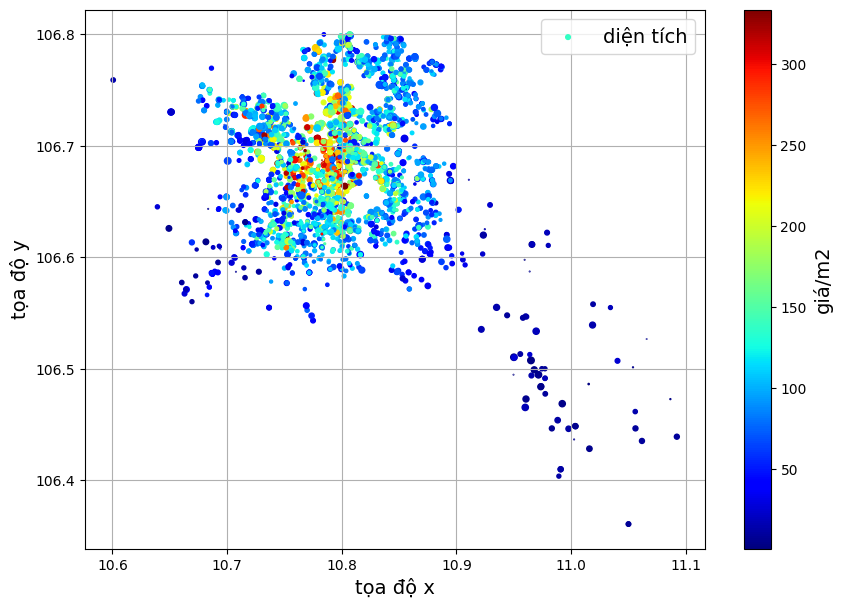

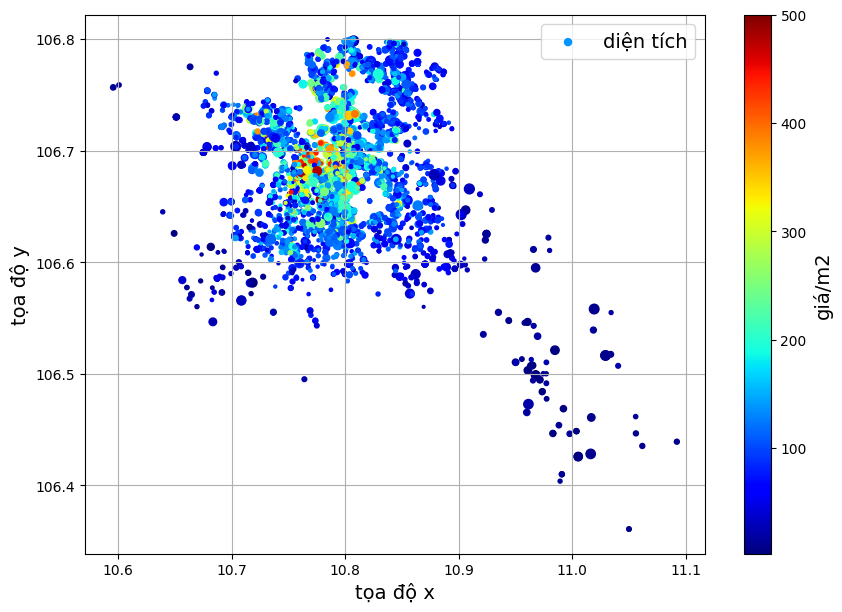

In [542]:
housing_1.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing_1["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
# save_fig("housing_1_prices_scatterplot")  # extra code

housing_2.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing_2["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
# save_fig("housing_2_prices_scatterplot")  # extra code

plt.show()




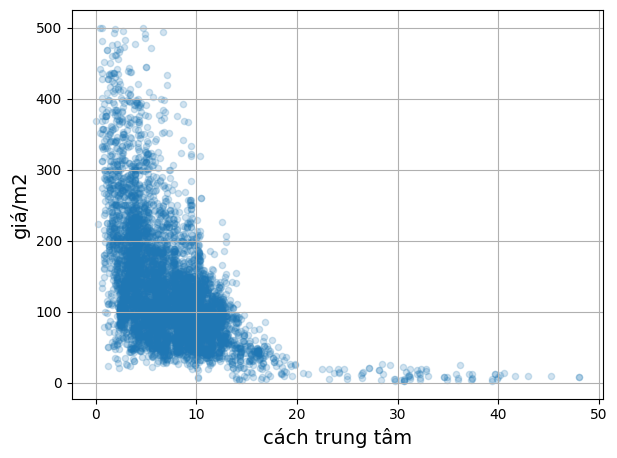

In [543]:
housing_2.plot(kind="scatter", x="cách trung tâm", y="giá/m2", grid=True, alpha=0.2)
save_fig("distance_center_vs_price_plot")  # extra code
plt.show()

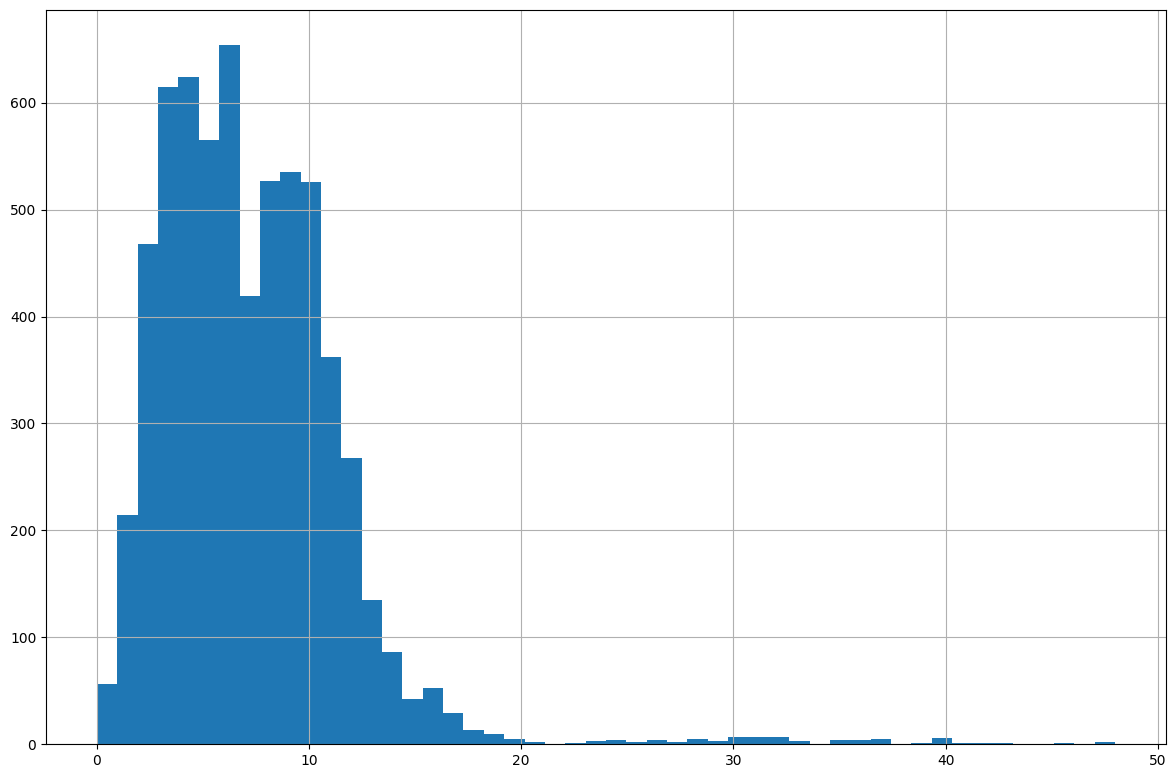

In [544]:
housing_2["cách trung tâm"].hist(bins=50, figsize=(12, 8))
save_fig("distance_center_histogram")  # extra code

data của khoảng cách tới trung tâm hơi lệch phải, ta sử dụng hàm log để tránh bị ảnh hưởng bởi outlier

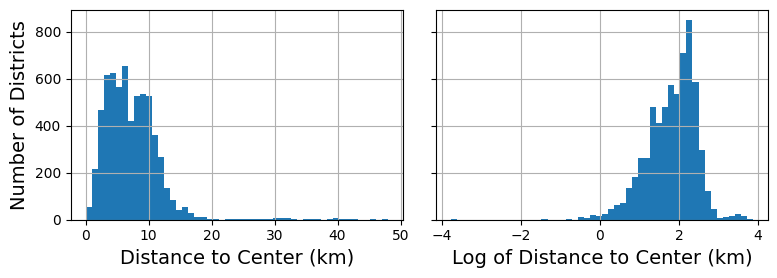

In [545]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["cách trung tâm"].hist(ax=axs[0], bins=50)
housing_2["cách trung tâm"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Distance to Center (km)")
axs[1].set_xlabel("Log of Distance to Center (km)")
axs[0].set_ylabel("Number of Districts")
save_fig("long_distance_center_plot")
plt.show()

Hàm log với distance to center không có quá nhiều thay đổi, ta quyết định sử dụng data gốc

## Giá trung bình theo quận

In [546]:
housing_test = housing_2.copy()
housing_test["district_mean_area"] = housing_test.groupby("địa chỉ")["giá/m2"].transform("mean")
mean_area = housing_test[["địa chỉ", "district_mean_area"]]
mean_area.drop_duplicates(inplace=True)
mean_area.sort_values(by="district_mean_area", ascending=False, inplace=True)
# Kết hợp với tên quận để dễ nhìn
for i in ADDRESS_:
    if ADDRESS_[i] in mean_area["địa chỉ"].values:
        mean_area.loc[mean_area["địa chỉ"] == ADDRESS_[i], "địa chỉ"] = i

print(mean_area)


          địa chỉ  district_mean_area
27434      quận 1          284.988223
33087      quận 3          254.993772
3736      quận 10          219.176519
8018    phú nhuận          195.499238
30652      quận 5          176.666351
4310     tân bình          168.347379
4745   bình thạnh          156.239216
8443       quận 2          153.071707
35615     quận 11          144.631552
3349       gò vấp          130.554683
20476      quận 7          129.515119
22597      quận 4          117.984500
7839      tân phú          115.672750
1326       quận 6          111.374510
6000       quận 9          104.345205
35495     thủ đức          103.135562
3179       quận 8          103.029632
28715    bình tân           94.774454
2201      quận 12           82.328153
28918      nhà bè           80.804053
31213  bình chánh           56.538353
4658      hóc môn           45.260128
5299      cần giờ           15.380000
3917       củ chi           11.841139


C:\Users\huy\AppData\Local\Temp\ipykernel_8248\1548478164.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_area.drop_duplicates(inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\1548478164.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_area.sort_values(by="district_mean_area", ascending=False, inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\1548478164.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'bình chánh' has dtype incompatible with int64, please explicitly cast to a compatible dtype fir

In [547]:
REAL_ESTATE_VAL = {
     0: 'căn hộ chung cư',
    1: 'chung cư mini, căn hộ dịch vụ', # X
    2: 'nhà riêng', 
    3: 'nhà biệt thự, liền kề',
    4: 'nhà mặt phố',
    5: 'shophouse, nhà phố thương mại', # X
    6: 'đất nền dự án', # X
    7: 'bán đất',
    8: 'condotel', # X
    9: 'kho nhà xưởng' # X
}


ADDRESS_VAL = {
    0: 'bình chánh',
    1: 'bình tân',
    2: 'bình thạnh',
    3: 'cần giờ',
    4: 'củ chi',
    5: 'gò vấp',
    6: 'hóc môn',
    7: 'nhà bè',
    8: 'phú nhuận',
    9: 'quận 1',
    10: 'quận 10',
    11: 'quận 11',
    12: 'quận 12',#
    13: 'quận 2',#
    14: 'quận 3',
    15: 'quận 4',
    16: 'quận 5',
    17: 'quận 6',
    18: 'quận 7',
    19: 'quận 8',
    20: 'quận 9',
    21: 'thủ đức',
    22: 'tân bình',
    23: 'tân phú'
}

In [548]:
# tạo mảng 2 chiều về giá trị trung bình của từng loại nhà đất theo từng quận
housing_test["type_district_mean_area"] = housing_test.groupby(["loại nhà đất", "địa chỉ"])["giá/m2"].transform("mean")
type_district_mean_area = housing_test[["loại nhà đất", "địa chỉ", "type_district_mean_area"]]
type_district_mean_area.drop_duplicates(inplace=True)   



C:\Users\huy\AppData\Local\Temp\ipykernel_8248\2789636472.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area.drop_duplicates(inplace=True)


In [549]:
type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)
print(type_district_mean_area)

                loại nhà đất    địa chỉ  type_district_mean_area
8443               nhà riêng     quận 2               142.328000
8018             nhà mặt phố  phú nhuận               303.957674
35495                bán đất    thủ đức                84.779496
35615              nhà riêng    quận 11               137.152121
1873   nhà biệt thự, liền kề     quận 2               235.760897
...                      ...        ...                      ...
22677  nhà biệt thự, liền kề   tân bình               326.706667
1251   nhà biệt thự, liền kề    quận 10               288.110000
365    nhà biệt thự, liền kề    quận 11               257.140000
1902                 bán đất  phú nhuận               149.670000
6478   nhà biệt thự, liền kề     quận 1               305.560000

[106 rows x 3 columns]


C:\Users\huy\AppData\Local\Temp\ipykernel_8248\997375264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\997375264.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)


In [550]:
pivot_table = type_district_mean_area.pivot_table(
    values="type_district_mean_area",
    index="địa chỉ",
    columns="loại nhà đất",
    aggfunc="mean"
)

pivot_table.round(2)

loại nhà đất,bán đất,căn hộ chung cư,"nhà biệt thự, liền kề",nhà mặt phố,nhà riêng
địa chỉ,,,,,
bình chánh,33.36,46.73,116.31,107.99,20.61
bình thạnh,124.83,106.03,187.28,243.01,149.85
bình tân,69.38,53.05,128.68,132.83,96.86
cần giờ,15.38,NaN,NaN,NaN,NaN
củ chi,11.42,NaN,NaN,NaN,18.13
gò vấp,86.69,53.75,200.56,172.88,123.81
hóc môn,36.39,NaN,59.52,52.45,50.20
nhà bè,49.07,53.17,113.67,91.93,92.89
phú nhuận,149.67,87.21,306.11,303.96,182.28


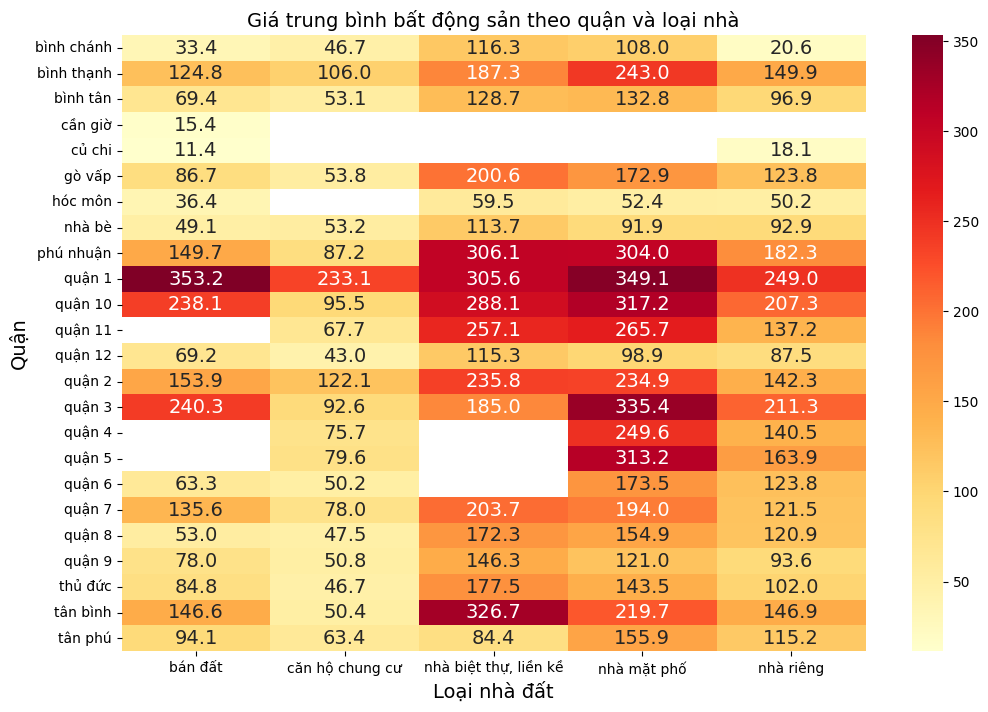

In [551]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlOrRd",
    fmt=".1f"
)

plt.title("Giá trung bình bất động sản theo quận và loại nhà")
plt.xlabel("Loại nhà đất")
plt.ylabel("Quận")

plt.show()

In [552]:
# Hiển thị giá trị trung bình của từng loại nhà đất theo từng quận, hiện theo dạng bảng dễ nhìn
# địa chỉ là cột dọc, loại nhà đất là cột ngang
# Nếu cột nào không chứa dữ liệu thì sẽ hiển thị NaN
from tabulate import tabulate
type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)
print(tabulate(type_district_mean_area, headers="keys", tablefmt="grid"))
# lưu bảng vào file csv
type_district_mean_area.to_csv("type_district_mean_area.csv", index=False)


+-------+----------------+-----------+---------------------------+
|       |   loại nhà đất |   địa chỉ |   type_district_mean_area |
+=======+================+===========+===========================+
|  8443 |            nan |       nan |                  142.328  |
+-------+----------------+-----------+---------------------------+
|  8018 |            nan |       nan |                  303.958  |
+-------+----------------+-----------+---------------------------+
| 35495 |            nan |       nan |                   84.7795 |
+-------+----------------+-----------+---------------------------+
| 35615 |            nan |       nan |                  137.152  |
+-------+----------------+-----------+---------------------------+
|  1873 |            nan |       nan |                  235.761  |
+-------+----------------+-----------+---------------------------+
| 20476 |            nan |       nan |                  193.974  |
+-------+----------------+-----------+------------------------

C:\Users\huy\AppData\Local\Temp\ipykernel_8248\2270891136.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\2270891136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)


# Nhận xét về giá/m2

Giá có vẻ đang có oulier khá lớn nên ta sẽ sử dụng hàm log để giảm sử ảnh hưởng của giá

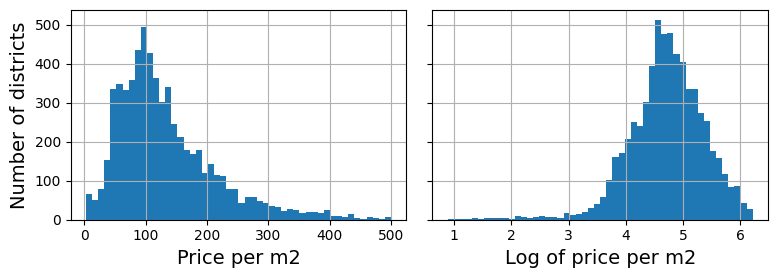

In [553]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["giá/m2"].hist(ax=axs[0], bins=50)
housing_2["giá/m2"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Price per m2")
axs[1].set_xlabel("Log of price per m2")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

## Nhận xét về diện tích

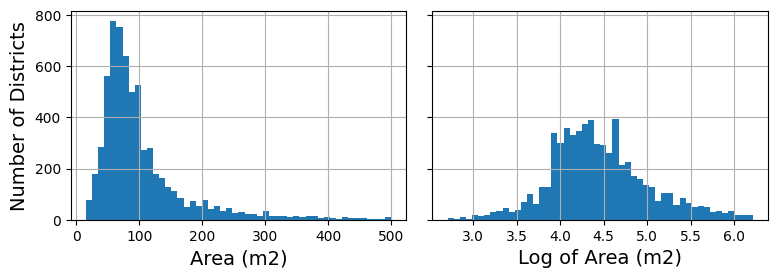

In [554]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["diện tích"].hist(ax=axs[0], bins=50)
housing_2["diện tích"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Area (m2)")
axs[1].set_xlabel("Log of Area (m2)")
axs[0].set_ylabel("Number of Districts")
save_fig("long_area_plot")
plt.show()

In [555]:
housing_2.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000
mean,2.573066,12.689589,102.854663,134.320135,5.297165,3.242120,10.791795,106.689518,3.150111,7.308374
std,2.065515,7.400572,72.203117,82.458519,2.460658,1.171134,0.051499,0.055236,1.028138,4.478850
min,0.000000,0.000000,15.000000,2.430000,1.000000,1.000000,10.595573,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,78.812500,4.000000,3.000000,10.757968,106.651023,3.000000,4.114470
50%,2.000000,13.000000,80.000000,113.725000,5.000000,3.000000,10.792568,106.691938,3.000000,6.674907
75%,4.000000,20.000000,118.000000,171.397500,5.000000,4.000000,10.823520,106.727768,3.000000,9.664700
max,7.000000,23.000000,500.000000,500.000000,20.000000,7.000000,11.092275,106.799964,11.000000,47.974788


## Train model

6️⃣ Một cải tiến rất đáng làm

Dataset của bạn có tọa độ.
Có thể thêm feature:

housing_2["area_density"] = housing_2["diện tích"] / housing_2["phòng ngủ"]

Hoặc:

housing_2["frontage_ratio"] = housing_2["mặt tiền"] / housing_2["diện tích"]

In [556]:
X_train = housing_2.drop(columns=["giá/m2"])
# X_train["diện tích"] = X_train["diện tích"].apply(np.log)
y_train = np.log(housing_2["giá/m2"])


set_median_none_in_column(test_set, ["số tầng", "phòng ngủ", "mặt tiền"])
X_test = test_set.drop(columns=["giá/m2"])
# X_test["diện tích"] = X_test["diện tích"].apply(np.log)
y_test = np.log(test_set["giá/m2"])

C:\Users\huy\AppData\Local\Temp\ipykernel_8248\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(median_value)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(median_value)
C:\Users\huy\AppData\Local\Temp\ipykernel_8248\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [557]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import joblib as jb

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps['model']

jb.dump(pipeline, "RandomForestRegressor.pkl")

['RandomForestRegressor.pkl']

In [558]:
X_train.columns

Index(['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'cách trung tâm'],
      dtype='object')

In [559]:
X_test.describe()

,loại nhà đất,địa chỉ,diện tích,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000,1775.000000
mean,2.759437,12.585915,117.531706,6.340039,4.083380,10.794795,106.685894,3.324507,7.368073
std,2.063026,7.254616,111.071723,8.843320,5.147085,0.053413,0.056279,1.392338,5.038830
min,0.000000,0.000000,1.000000,1.000000,1.000000,10.600678,106.404037,1.000000,0.084247
25%,2.000000,6.500000,60.000000,4.000000,3.000000,10.765730,106.648927,3.000000,3.933183
50%,2.000000,13.000000,83.200000,5.000000,3.000000,10.793500,106.688991,3.000000,6.678884
75%,4.000000,20.000000,128.000000,5.535000,4.000000,10.828490,106.723921,4.000000,9.663033
max,7.000000,23.000000,996.000000,276.000000,87.000000,11.060657,106.799943,25.000000,42.906853


In [560]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model = jb.load("RandomForestRegressor.pkl")
pred = model.predict(X_test)

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return rmse, mae, r2

rmse, mae, r2 = evaluate_model(model, X_test, y_test)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")
print("RMSE: " + str(rmse))

MAE: 0.22
R2: 0.80
RMSE: 0.3427297631484817


In [561]:
price_pred = np.exp(pred)

In [562]:
price_pred[:10]

array([112.72955891, 350.83464705, 164.34812198, 257.77521087,
        82.43936699, 187.09465386,  85.27025708, 181.55883123,
       237.01598483, 118.38637114])

# Kiểm tra feature quan trọng

In [563]:
import pandas as pd

importance = pd.Series(
    model['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

cách trung tâm    0.524742
loại nhà đất      0.176154
tọa độ x          0.081594
tọa độ y          0.065884
diện tích         0.062373
số tầng           0.043565
địa chỉ           0.019034
mặt tiền          0.016522
phòng ngủ         0.010132
dtype: float64


Top 3 features:
- distance_center_km
- loại nhà đất
- tọa độ

Ba đặc trưng quan trọng nhất chiếm hơn 75% tổng độ quan trọng của mô hình, cho thấy vị trí và loại hình bất động sản là các yếu tố quyết định chính đến giá.

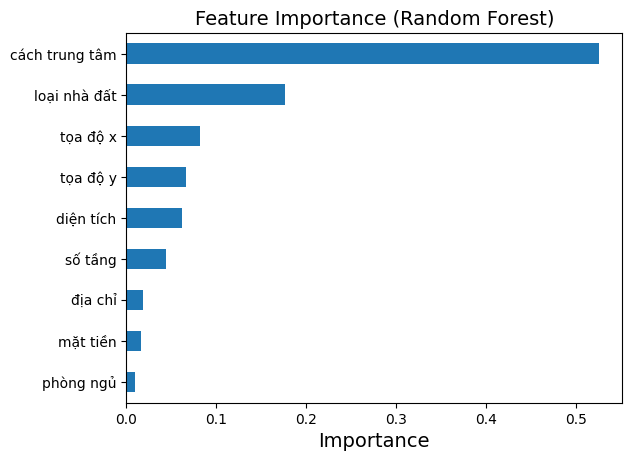

In [564]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## Load model to test

In [565]:
pipeline = jb.load("RandomForestRegressor.pkl")

median = pipeline.named_steps['imputer'].statistics_
model = pipeline.named_steps['model']

median_series = pd.Series(median, index=X_train.columns)

In [566]:
print(X_train.columns)

Index(['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'cách trung tâm'],
      dtype='object')


In [567]:
# {"loại nhà đất": 0, "địa chỉ": 2, "giá": 9500.0, "diện tích": 80.0, "giá/m2": 118.75, "mặt tiền": null, "phòng ngủ": 2, "pháp lý": 1, "tọa độ": null, 
# "tọa độ x": 10795419054.8442, "tọa độ y": 106719977458.315, "số tầng": null}


test_data = pd.DataFrame({
    'loại nhà đất': [0],
    'địa chỉ': [2],
    'diện tích': [80],
    'mặt tiền': [None],
    'phòng ngủ': [2],
    # 'pháp lý': [1],
    'tọa độ x': [10795419054.8442 / 1000000000],
    'tọa độ y': [106719977458.315 / 1000000000],
    'số tầng': [None]
})

test_data["cách trung tâm"] = haversine(
    test_data["tọa độ x"],
    test_data["tọa độ y"],
    lat,
    lon
)
# fill missing values with median
test_data.fillna(median_series, inplace=True)

# print(test_data)
# 10.7795105160091,106.624395422216
predicted_price_per_m2 = np.exp(model.predict(test_data))
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0]:.5f} triệu/m2")
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0] * np.exp(test_data['diện tích'][0]):.5f} triệu")

Giá dự đoán cho nhà đất: 116.00039 triệu/m2
Giá dự đoán cho nhà đất: 6427143475532561822452123351155474432.00000 triệu


C:\Users\huy\AppData\Local\Temp\ipykernel_8248\1693592102.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.fillna(median_series, inplace=True)
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## Train thêm model 
LinearRegression, DecisionTree, KNearestNeightbor, XGBoost

In [568]:
# Chạy thêm các model: LinearRegression, DecisionTree, KNearestNeightbor, XGBoost

import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

# Thêm lưu model trong m
pipeline_list = [
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression())
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", KNeighborsRegressor())
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(random_state=42))
    ])
]
models = {}


for pipe in pipeline_list:
    # train
    pipe.fit(X_train, y_train)

    # lấy tên model
    model_name = pipe.named_steps["model"].__class__.__name__

    # lưu model
    joblib.dump(pipe, f"{model_name}.pkl")
    models[model_name] = pipe
    print(f"Saved {model_name}.pkl")


Saved LinearRegression.pkl
Saved DecisionTreeRegressor.pkl
Saved KNeighborsRegressor.pkl
Saved XGBRegressor.pkl


In [569]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return rmse, mae, r2

for model_name, model in models.items():
    rmse, mae, r2 = evaluate_model(model.named_steps["model"], X_test, y_test)
    print(f"{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")


pipeline = jb.load("RandomForestRegressor.pkl")
rmse, mae, r2 = evaluate_model(pipeline.named_steps["model"], X_test, y_test)

print(f"RandomForestRegressor - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")


LinearRegression - RMSE: 0.63, MAE: 0.42, R2: 0.31
DecisionTreeRegressor - RMSE: 0.43, MAE: 0.29, R2: 0.68
KNeighborsRegressor - RMSE: 0.54, MAE: 0.35, R2: 0.49
XGBRegressor - RMSE: 0.38, MAE: 0.24, R2: 0.75


C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


RandomForestRegressor - RMSE: 0.34, MAE: 0.22, R2: 0.80


| Mô hình                 | RMSE | MAE  | R²   |
| ----------------------- | ---- | ---- | ---- |
| Linear Regression       | 0.59 | 0.41 | 0.38 |
| Decision Tree Regressor | 0.40 | 0.27 | 0.71 |
| KNeighbors Regressor    | 0.52 | 0.35 | 0.51 |
| XGBoost Regressor       | 0.35 | 0.24 | 0.78 |
| Random Forest Regressor | 0.33 | 0.22 | 0.81 |


## Phân tích kết quả
- Kết quả thực nghiệm cho thấy mô hình Linear Regression cho hiệu quả thấp nhất với hệ số R² chỉ đạt 0.22. Điều này cho thấy mối quan hệ giữa các thuộc tính bất động sản và giá bán không mang tính tuyến tính đơn giản.

- Mô hình Decision Tree Regressor cải thiện đáng kể kết quả so với Linear Regression với R² đạt 0.69. Điều này cho thấy các mô hình dựa trên cây có khả năng nắm bắt các mối quan hệ phi tuyến trong dữ liệu tốt hơn.

- Mô hình K-Nearest Neighbors cho kết quả trung bình với R² đạt 0.49. Phương pháp này phụ thuộc nhiều vào khoảng cách giữa các điểm dữ liệu nên dễ bị ảnh hưởng bởi nhiễu và sự phân bố không đồng đều của dữ liệu.

- Hai mô hình cho kết quả tốt nhất là Random Forest Regressor và XGBoost Regressor, với R² đạt khoảng 0.78 và sai số RMSE thấp nhất. Điều này cho thấy các mô hình ensemble dựa trên nhiều cây quyết định có khả năng học được các mối quan hệ phức tạp trong dữ liệu bất động sản.

Dựa trên kết quả thực nghiệm, mô hình Random Forest Regressor được lựa chọn làm mô hình chính của hệ thống.

Lý do lựa chọn Random Forest bao gồm:

+ Khả năng dự đoán chính xác với sai số thấp

+ Ít bị overfitting hơn so với Decision Tree đơn lẻ

+ Hoạt động ổn định với dữ liệu có nhiều đặc trưng khác nhau

+ Cho phép phân tích mức độ quan trọng của các đặc trưng (feature importance)

Mô hình sau khi huấn luyện được lưu lại dưới dạng file .pkl để phục vụ cho việc tích hợp vào hệ thống web trong bước triển khai tiếp theo.

## FINE-TURNING

In [570]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [10,20,30,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

rf = RandomForestRegressor()

search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

In [571]:
rmse, mae, r2 = evaluate_model(best_model, X_test, y_test)
print(f"Best RandomForestRegressor - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

Best RandomForestRegressor - RMSE: 0.34, MAE: 0.22, R2: 0.80


In [572]:
search.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 30}

In [573]:
jb.dump(best_model, "Best_RandomForestRegressor.pkl")

['Best_RandomForestRegressor.pkl']

In [574]:
import joblib as jb
import numpy as np
import pandas as pd

pipeline = jb.load("RandomForestRegressor.pkl")
median = pipeline.named_steps['imputer'].statistics_
model = pipeline.named_steps['model']

X_train_columns = ['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'distance_center_km']
median_series = pd.Series(median, index=X_train_columns)

lat = 10.7769
lon = 106.7009

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + \
        np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))

    return R*c

# {"loại nhà đất": 0, "địa chỉ": 2, "giá": 9500.0, "diện tích": 80.0, "giá/m2": 118.75, "mặt tiền": null, "phòng ngủ": 2, "pháp lý": 1, "tọa độ": null, 
# "tọa độ x": 10795419054.8442, "tọa độ y": 106719977458.315, "số tầng": null}



test_data = pd.DataFrame({
    'loại nhà đất': [0],
    'địa chỉ': [2],
    'diện tích': [80],
    'mặt tiền': [None],
    'phòng ngủ': [2],
    # 'pháp lý': [1],
    'tọa độ x': [10795419054.8442 / 1000000000],
    'tọa độ y': [106719977458.315 / 1000000000],
    'số tầng': [None]
})

test_data["distance_center_km"] = haversine(
    test_data["tọa độ x"],
    test_data["tọa độ y"],
    lat,
    lon
)
# fill missing values with median
test_data.fillna(median_series, inplace=True)

# print(test_data)
# 10.7795105160091,106.624395422216
predicted_price_per_m2 = np.exp(model.predict(test_data))
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0]:.5f} triệu/m2")
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0] * test_data['diện tích'][0]:.5f} triệu")

Giá dự đoán cho nhà đất: 116.00039 triệu/m2
Giá dự đoán cho nhà đất: 9280.03106 triệu


C:\Users\huy\AppData\Local\Temp\ipykernel_8248\136863481.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.fillna(median_series, inplace=True)
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [575]:
for i in df.value_counts("loại nhà đất").index:
    for j in REAL_ESTATE_:
        if i == REAL_ESTATE_[j]:
            print(f"{j}: {df.value_counts('loại nhà đất')[i]}") 

nhà riêng: 3526
nhà mặt phố: 1924
căn hộ chung cư: 1733
bán đất: 1097
nhà biệt thự, liền kề: 593
